# Lecture Week 5: Cleaning Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
polls = pd.read_csv('./data/president_polls_2016.csv')
polls.shape #row, col

(12624, 27)

<img src="parent directory.jpg" width="500">


<img src="branch.jpg" width="300">

**.** means the **current folder**

**/data** means enter the **data subfolder**

**/president_polls_2016.csv** is the **dataset to read**

## What the info() method can tell you

In [5]:
polls.info(verbose=True, # info for all of the columns
           memory_usage='deep', # acurate memory
           show_counts=True  #  show non-null counts
                             # helping identify columns containing missing values.
                             # why?
          )

<class 'pandas.DataFrame'>
RangeIndex: 12624 entries, 0 to 12623
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cycle             12624 non-null  int64  
 1   branch            12624 non-null  str    
 2   type              12624 non-null  str    
 3   matchup           12624 non-null  str    
 4   forecastdate      12624 non-null  str    
 5   state             12624 non-null  str    
 6   startdate         12624 non-null  str    
 7   enddate           12624 non-null  str    
 8   pollster          12624 non-null  str    
 9   grade             11337 non-null  str    
 10  samplesize        12621 non-null  float64
 11  population        12624 non-null  str    
 12  poll_wt           12624 non-null  float64
 13  rawpoll_clinton   12624 non-null  float64
 14  rawpoll_trump     12624 non-null  float64
 15  rawpoll_johnson   8397 non-null   float64
 16  rawpoll_mcmullin  90 non-null     float64
 17  adjp

**Tips**:

The number of non-null elements in some columns is less than the number of rows, so there are missing values in those columns.

Ex:

Number of rows: 12624

non-null in adjpoll_mcmullin = 90 non-null

In [8]:
# polls.adjpoll_mcmullin[:10]
# polls.multiversions[10:20]

In [7]:
# NOTE: This may take a long time to run
jobs = pd.read_excel('./data/oesm18all/all_data_M_2018.xlsx')
jobs.shape

(403895, 30)

In [9]:
jobs.info(verbose=True, memory_usage='deep', show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 403895 entries, 0 to 403894
Data columns (total 30 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   area          403895 non-null  int64 
 1   area_title    403895 non-null  str   
 2   area_type     403895 non-null  int64 
 3   naics         403895 non-null  str   
 4   naics_title   403895 non-null  str   
 5   i_group       403895 non-null  str   
 6   own_code      403895 non-null  int64 
 7   occ_code      403895 non-null  str   
 8   occ_title     403895 non-null  str   
 9   o_group       403895 non-null  str   
 10  tot_emp       403895 non-null  object
 11  emp_prse      403895 non-null  object
 12  jobs_1000     227944 non-null  object
 13  loc_quotient  227944 non-null  object
 14  pct_total     169080 non-null  object
 15  h_mean        403895 non-null  object
 16  a_mean        403895 non-null  object
 17  mean_prse     403895 non-null  object
 18  h_pct10       403895 non-null  obje

## What the unique values can tell you

In [11]:
polls.shape

(12624, 27)

In [13]:
polls.columns.tolist()

['cycle',
 'branch',
 'type',
 'matchup',
 'forecastdate',
 'state',
 'startdate',
 'enddate',
 'pollster',
 'grade',
 'samplesize',
 'population',
 'poll_wt',
 'rawpoll_clinton',
 'rawpoll_trump',
 'rawpoll_johnson',
 'rawpoll_mcmullin',
 'adjpoll_clinton',
 'adjpoll_trump',
 'adjpoll_johnson',
 'adjpoll_mcmullin',
 'multiversions',
 'url',
 'poll_id',
 'question_id',
 'createddate',
 'timestamp']

Missing values such as NaN may appear as one of the unique values.

In [15]:
polls.nunique() # number of unique values in each column

cycle                   1
branch                  1
type                    3
matchup                 1
forecastdate            1
state                  57
startdate             352
enddate               345
pollster              196
grade                  10
samplesize           1766
population              4
poll_wt              4399
rawpoll_clinton      1312
rawpoll_trump        1385
rawpoll_johnson       584
rawpoll_mcmullin       16
adjpoll_clinton     12569
adjpoll_trump       12582
adjpoll_johnson      6629
adjpoll_mcmullin       57
multiversions           1
url                  1304
poll_id              4208
question_id          4208
createddate           222
timestamp               3
dtype: int64

**```df.apply(func)```** allows you to run the **same function** across a DataFrame on **every column**.

```.apply()``` works **column by column** by default (```axis=0```).

**```polls.apply(pd.unique())```** applies ```pd.unique()``` to each column of the polls DataFrame and returns the distinct values found in every column.

In [17]:
polls.apply(pd.unique)

cycle                                                          [2016]
branch                                                    [President]
type                               [polls-plus, now-cast, polls-only]
matchup                               [Clinton vs. Trump vs. Johnson]
forecastdate                                                [11/8/16]
state               [U.S., New Mexico, Virginia, Iowa, Wisconsin, ...
startdate           [11/3/2016, 11/1/2016, 11/2/2016, 11/4/2016, 1...
enddate             [11/6/2016, 11/7/2016, 11/5/2016, 11/4/2016, 1...
pollster            [ABC News/Washington Post, Google Consumer Sur...
grade                       [A+, B, A-, B-, A, nan, B+, C+, C-, C, D]
samplesize          [2220.0, 26574.0, 2195.0, 3677.0, 16639.0, 129...
population                                             [lv, rv, a, v]
poll_wt             [8.720654, 7.628472, 6.424334, 6.087135, 5.316...
rawpoll_clinton     [47.0, 38.03, 42.0, 45.0, 48.0, 44.0, 46.0, 41...
rawpoll_trump       

## What the ```.value_counts``` can tell you?

```.value_counts()``` counts **how many times** each **unique value** appears in a **column**.

<div style="margin-right: 50px; justify-content: center; gap: 60px;">
  <img src="vluecounts.jpg" width="40%">
    
  <img src="r.jpg" width="30%">
</div>

```python
DataFrame.value_counts(
                       normalize=False, # Return proportions rather than frequencies.
                       ascending=False, 
                       dropna=True # exclude counts of rows that contain NA values
                      )


In [21]:
# Apply the 'value_counts' method on the 'state' column
# value is the count of occurrences in the column
state_counts = polls.state.value_counts() # ascending=False
### how many times each unique valus in col state?

# print("state_counts:\n",state_counts)

# This will return the top 4 most frequent values in the 'state' column
top_states = state_counts.head(4)
display(top_states)

state
U.S.              3318
Florida            444
North Carolina     375
Pennsylvania       375
Name: count, dtype: int64

- ```print()```  The result has **simple text formatting** and may be less readable for large DataFrames.

- ```display()``` Uses Jupyter’s **rich formatting** and shows a DataFrame as a formatted HTML table with clearer rows, columns, and styling.

In [27]:
# print(polls.head(3))
display(polls.head(3))

,cycle,branch,type,matchup,forecastdate,state,startdate,enddate,pollster,grade,...,adjpoll_clinton,adjpoll_trump,adjpoll_johnson,adjpoll_mcmullin,multiversions,url,poll_id,question_id,createddate,timestamp
0,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/3/2016,11/6/2016,ABC News/Washington Post,A+,...,45.20163,41.72430,4.626221,NaN,NaN,https://www.washingtonpost.com/news/the-fix/wp...,48630,76192,11/7/16,09:35:33 8 Nov 2016
1,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/1/2016,11/7/2016,Google Consumer Surveys,B,...,43.34557,41.21439,5.175792,NaN,NaN,https://datastudio.google.com/u/0/#/org//repor...,48847,76443,11/7/16,09:35:33 8 Nov 2016
2,2016,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/2/2016,11/6/2016,Ipsos,A-,...,42.02638,38.81620,6.844734,NaN,NaN,http://projects.fivethirtyeight.com/polls/2016...,48922,76636,11/8/16,09:35:33 8 Nov 2016


In [29]:
# Reminders from week 2
# Different ways of selecting a column
print(polls.state[17:20]) ### only for one column, where the label is without spaces.
print()
print(polls['state'][17:20])

17         Wisconsin
18    North Carolina
19           Georgia
Name: state, dtype: str

17         Wisconsin
18    North Carolina
19           Georgia
Name: state, dtype: str


Now we change the default option to:
```python
normalize=True

In [33]:
# Returns a Series object where the index is each unique value in the 'state' column, 
# and the count is the proportion of occurrences of that value in the 'state' column
state_proportions = polls.state.value_counts(normalize=True)

# Use the 'head' method to return the first 3 rows of the 'state_proportions' Series object
# This will return a new Series object containing the proportions of 
# the top 3 most frequent values in the 'state' column
top_states_proportions = state_proportions.head(3)
display(top_states_proportions)

total = sum(state_proportions)
print("\nsummation of proportions:",total) # almost 1 or 100%

state
U.S.              0.262833
Florida           0.035171
North Carolina    0.029705
Name: proportion, dtype: float64


summation of proportions: 0.9999999999999993


Now we change the default option to:
```python
dropna=False

In [39]:
# Apply the 'value_counts' method on the 'multiversions' column of 
# the 'polls' DataFrame, with the 'dropna' parameter set to False
# This method returns a Series object where the index is each unique value 
# in the 'multiversions' column, and the value is the count of occurrences of that value in the column
multiversions_counts_dropna = polls.multiversions.value_counts(dropna=True)
print(multiversions_counts_dropna.head(3))

print("**************************")

multiversions_counts = polls.multiversions.value_counts(dropna=False)
print(multiversions_counts.head(3))
# multiversions_counts = polls['multiversions'].value_counts(dropna=False)

multiversions
*    36
Name: count, dtype: int64
**************************
multiversions
NaN    12588
*         36
Name: count, dtype: int64


In [43]:
polls.multiversions.info() # 36 non-null -> real values

<class 'pandas.Series'>
RangeIndex: 12624 entries, 0 to 12623
Series name: multiversions
Non-Null Count  Dtype
--------------  -----
36 non-null     str  
dtypes: str(1)
memory usage: 98.8 KB


#### Use ```.value_counts()``` with Multiple Columns

In [45]:
# Select the 'state' and 'grade' columns from the 'polls' DataFrame object
# Apply the 'value_counts' method on the resulting DataFrame object
# This method returns a Series object where the index is a unique combination of values 
# form the 'state' and 'grade' columns,
# and the value is the count of occurrences of that combination in the DataFrame
state_grade_counts = polls[['state', 'grade']].value_counts() # two-level index
# print(state_grade_counts.index)
display(state_grade_counts)

state          grade
U.S.           A-       1215
               C+        546
               B         162
               C-        126
               A+        114
                        ... 
New York       B+          3
Illinois       A           3
Mississippi    B+          3
West Virginia  B-          3
Utah           A           3
Name: count, Length: 321, dtype: int64

# Simplify Data
## How to drop rows and columns

```df.drop()``` can drop **both rows and columns**.

By **default**, it drops **rows**:

- ```f.drop(2)``` -> Drops the row with index label 2 (third row).

- To drop a column: ```df.drop(columns=['column1_name', 'column2_name', ...])```

``` python
df.drop(index=[0, 2, ...])              # Drop rows
df.drop(columns=['col1_name', 'col2_name',...])     # Drop a column 
```

In [53]:
polls = pd.read_csv('./data/president_polls_2016.csv')
# polls.nunique()
print(polls.shape)

(12624, 27)


In [55]:
polls2 = polls.drop(columns=['cycle','forecastdate'])
print(polls2.shape)

(12624, 25)


If any of the specified **columns are not found** in the DataFrame, an **error is 
raised** (this is controlled by the `errors` parameter).

In [66]:
polls = pd.read_csv('./data/president_polls_2016.csv')

# Drop specified columns from the DataFrame:
# The `drop()` method is used to remove the specified columns or rows from the DataFrame.
# We pass a list of column names to be dropped to the `columns` parameter.
# The `inplace` parameter is set to `True` to modify the DataFrame in place, 
# rather than returning a new modified DataFrame.
polls.drop(columns=['cycle', 'forecastdate'], errors='raise', inplace=True) 
# returns None, does not create a new df, modifies heoriginal one. 
# So, you cannot define it as a new df.
print(polls.shape)
# polls.head()

(12624, 25)


### drop rows
1. Drop rows by index label: ```df = df.drop(index=[0, 2])```
2. Drop rows using a condition: ```df = df[df['age'] >= 18]``` or ```df = df.query("age >= 18")```

In [3]:
import pandas as pd
polls = pd.read_csv('./data/president_polls_2016.csv')
print(polls.type.value_counts())
print(polls.shape[0])

type
polls-plus    4208
now-cast      4208
polls-only    4208
Name: count, dtype: int64
12624


In [9]:
# Filter the 'polls' DataFrame object 
# to include only rows where the 'type' column 
# is equal to "now-cast", using the 'query' method
polls = polls.query('type == "now-cast"')

# Alternatively,

# filter the 'polls' DataFrame object 
# to include only rows where the 'type' column 
# is equal to "now-cast", 
# using boolean indexing with a condition inside square brackets
polls = polls[polls.type == 'now-cast']
print(polls.type[:10])
# display(polls.head(3))

4208    now-cast
4209    now-cast
4210    now-cast
4211    now-cast
4212    now-cast
4213    now-cast
4214    now-cast
4215    now-cast
4216    now-cast
4217    now-cast
Name: type, dtype: str


In [13]:
print(polls.shape)
polls_drop_row = polls.drop(index = polls.index[0:4200])
print(polls_drop_row.shape)

(4208, 27)
(8, 27)


### fires datafarme

In [17]:
fires = pd.read_csv('./data/fires.csv')
display(fires.head(3))

,STATE,FIRE_YEAR,DISCOVERY_DATE,FIRE_NAME,FIRE_SIZE,LATITUDE,LONGITUDE
0,CA,2005,2005-02-02 00:00:00,FOUNTAIN,0.10,40.036944,-121.005833
1,CA,2004,2004-05-12 00:00:00,PIGEON,0.25,38.933056,-120.404444
2,CA,2004,2004-05-31 00:00:00,SLACK,0.10,38.984167,-120.735556


Ex: Converts all column names in the fires DataFrame to lowercase.

In [22]:
# fires.columns accesses the column names.
# .str allows string operations on every column name.
# .lower() converts each name to lowercase.
fires.columns = fires.columns.str.lower()
display(fires.head(3))

,state,fire_year,discovery_date,fire_name,fire_size,latitude,longitude
0,CA,2005,2005-02-02 00:00:00,FOUNTAIN,0.10,40.036944,-121.005833
1,CA,2004,2004-05-12 00:00:00,PIGEON,0.25,38.933056,-120.404444
2,CA,2004,2004-05-31 00:00:00,SLACK,0.10,38.984167,-120.735556


## ```df.duplicated()```
Checks for repeated rows and returns a **Boolean Series**:

- ```False```: the row is unique or the first occurrence
- ```True```: the row appeared earlier
<img src="duplicate.png" width="400">

  ``` python
  df.duplicated(keep='first')  # Mark later copies
  df.duplicated(keep='last')   # Mark earlier copies
  df.duplicated(keep=False)    # Mark all occurrences
 ```

### Example:

<div style="text-align: center;">
    <img src="dup.jpg" width="200">
  </div>
  
- ```keep='first'``` is the **default**, which **keeps the first occurrence** unmarked and **marks only later copies** as duplicates.
<div style="display: flex; gap: 20px;">
    <img src="dupfirst.jpg" width="200">
    <img src="dup1.jpg" width="400">
</div>

- ```keep=False``` **marks every occurrence** of a duplicated row, including the first one.
<div style="display: flex; gap: 1000px;">
    <img src="dupF.jpg" width="200">
    <img src="dup2.jpg" width="400">
</div>

Ex: Select duplicate rows based on all columns:

In [25]:
# The `duplicated()` method returns a boolean mask indicating 
# which rows are duplicated.
# When `keep` is set to `False`, all occurrences of a 
# duplicated row are marked as `True`.
# We then use this boolean mask to select only the rows with `True` values, 
# which correspond to the duplicated rows.
duplicated_rows = fires[fires.duplicated(keep=False)]
display(duplicated_rows)

,state,fire_year,discovery_date,fire_name,fire_size,latitude,longitude
48642,CA,1992,1992-06-28 00:00:00,NaN,0.1,36.021667,-118.805000
48644,CA,1992,1992-06-28 00:00:00,NaN,0.1,36.021667,-118.805000
71593,WA,1994,1994-08-06 00:00:00,NaN,0.1,46.441667,-121.783333
189841,WA,1992,1992-09-06 00:00:00,NaN,0.1,47.908200,-117.992700
193186,MT,1992,1992-08-14 00:00:00,NaN,2.0,45.083300,-107.534000
...,...,...,...,...,...,...,...
1871739,CA,2015,2015-12-20 00:00:00,DEER HOLLOW WY / PEPPERCO,0.1,33.458184,-117.086954
1871904,CA,2015,2015-12-20 00:00:00,DEER HOLLOW WY / PEPPERCO,0.1,33.458184,-117.086954
1872000,CA,2015,2015-12-20 00:00:00,DEER HOLLOW WY / PEPPERCO,0.1,33.458184,-117.086954
1876440,CA,2015,2015-05-19 00:00:00,NaN,1.0,34.003623,-117.167418


**`df.drop_duplicates()`**

- The `df.drop_duplicates()` method removes all duplicate **rows** from the DataFrame.
- When `keep` is set to `'first'`, only the first occurrence of each duplicated row is kept.
- The resulting DataFrame contains **unique rows** based on **all columns** except the first occurrence.

In [27]:
# Drop duplicates based on all columns except for the first occurrence:
unique_fires = fires.drop_duplicates(keep='first')
display(unique_fires)

,state,fire_year,discovery_date,fire_name,fire_size,latitude,longitude
0,CA,2005,2005-02-02 00:00:00,FOUNTAIN,0.10,40.036944,-121.005833
1,CA,2004,2004-05-12 00:00:00,PIGEON,0.25,38.933056,-120.404444
2,CA,2004,2004-05-31 00:00:00,SLACK,0.10,38.984167,-120.735556
3,CA,2004,2004-06-28 00:00:00,DEER,0.10,38.559167,-119.913333
4,CA,2004,2004-06-28 00:00:00,STEVENOT,0.10,38.559167,-119.933056
...,...,...,...,...,...,...,...
1880460,CA,2015,2015-09-26 00:00:00,ODESSA 2,0.01,40.481637,-122.389375
1880461,CA,2015,2015-10-05 00:00:00,NaN,0.20,37.617619,-120.938570
1880462,CA,2015,2015-05-02 00:00:00,NaN,0.10,37.617619,-120.938570
1880463,CA,2015,2015-10-14 00:00:00,NaN,2.00,37.672235,-120.898356


## How to rename columns

The `rename()` method is used to rename the specified columns in the DataFrame.
We pass a dictionary of old column names to new column names to the `columns` parameter.
The old column names are specified as keys and the new names as values.

In [33]:
polls = pd.read_csv('./data/president_polls_2016.csv')
polls.columns

Index(['cycle', 'branch', 'type', 'matchup', 'forecastdate', 'state',
       'startdate', 'enddate', 'pollster', 'grade', 'samplesize', 'population',
       'poll_wt', 'rawpoll_clinton', 'rawpoll_trump', 'rawpoll_johnson',
       'rawpoll_mcmullin', 'adjpoll_clinton', 'adjpoll_trump',
       'adjpoll_johnson', 'adjpoll_mcmullin', 'multiversions', 'url',
       'poll_id', 'question_id', 'createddate', 'timestamp'],
      dtype='str')

 Ex: Rename specified columns in the DataFrame using a dictionary:

In [35]:
# Rename specified columns in the DataFrame:
# The `polls` DataFrame is assigned to the modified DataFrame returned by `rename()`.
polls = polls.rename(columns={'rawpoll_clinton': 'clinton_pct', 'rawpoll_trump': 'trump_pct'})
print(polls.columns)

Index(['cycle', 'branch', 'type', 'matchup', 'forecastdate', 'state',
       'startdate', 'enddate', 'pollster', 'grade', 'samplesize', 'population',
       'poll_wt', 'clinton_pct', 'trump_pct', 'rawpoll_johnson',
       'rawpoll_mcmullin', 'adjpoll_clinton', 'adjpoll_trump',
       'adjpoll_johnson', 'adjpoll_mcmullin', 'multiversions', 'url',
       'poll_id', 'question_id', 'createddate', 'timestamp'],
      dtype='str')


In [60]:
# We define a dictionary `polls_names_dict` that maps old column names to new column names.
# The `rename()` method is used to rename the specified columns 
# in the DataFrame, using the dictionary.
# The `inplace` parameter is set to `True` to modify the DataFrame in place, 
# rather than returning a new modified DataFrame.
polls_names_dict = {'rawpoll_clinton': 'clinton_pct', 'rawpoll_trump': 'trump_pct'}
polls.rename(columns=polls_names_dict, inplace=True)
polls.columns

Index(['cycle', 'branch', 'type', 'matchup', 'forecastdate', 'state',
       'startdate', 'enddate', 'pollster', 'grade', 'samplesize', 'population',
       'poll_wt', 'clinton_pct', 'trump_pct', 'rawpoll_johnson',
       'rawpoll_mcmullin', 'adjpoll_clinton', 'adjpoll_trump',
       'adjpoll_johnson', 'adjpoll_mcmullin', 'multiversions', 'url',
       'poll_id', 'question_id', 'createddate', 'timestamp'],
      dtype='str')

Ex: Remove '_pct' from column names using the `str.replace()` method:

```python
df['col'].str.replace('old', 'new', regex=False)
```


This replaces text within every string value of the col column.

In [64]:
# The `columns` attribute of a pandas DataFrame contains the column labels.
# We apply the `str.replace()` method to each column label in the DataFrame `polls.columns`.
# The `'_pct'` string is replaced with an empty string `''` using the `str.replace()` method.
# The resulting modified column labels are then assigned back to the `columns` 
# attribute of the DataFrame using `polls.columns = ...`.
print(polls.columns)  # FRAOM PREVIOUS STEP
print("******************")
polls.columns = polls.columns.str.replace('_pct', '')
polls.columns

Index(['cycle', 'branch', 'type', 'matchup', 'forecastdate', 'state',
       'startdate', 'enddate', 'pollster', 'grade', 'samplesize', 'population',
       'poll_wt', 'clinton_pct', 'trump_pct', 'rawpoll_johnson',
       'rawpoll_mcmullin', 'adjpoll_clinton', 'adjpoll_trump',
       'adjpoll_johnson', 'adjpoll_mcmullin', 'multiversions', 'url',
       'poll_id', 'question_id', 'createddate', 'timestamp'],
      dtype='str')
******************


Index(['cycle', 'branch', 'type', 'matchup', 'forecastdate', 'state',
       'startdate', 'enddate', 'pollster', 'grade', 'samplesize', 'population',
       'poll_wt', 'clinton', 'trump', 'rawpoll_johnson', 'rawpoll_mcmullin',
       'adjpoll_clinton', 'adjpoll_trump', 'adjpoll_johnson',
       'adjpoll_mcmullin', 'multiversions', 'url', 'poll_id', 'question_id',
       'createddate', 'timestamp'],
      dtype='str')

Ex: Rename columns with regex using the `str.replace()` method:

```regex=True``` tells pandas to treat the search text as a **regular expression (pattern) rather than literal text.**

Here, ```^a_``` means “a_ only at the beginning”:

```a_salary```       → ```annual_salary```

```total_a_salary``` → unchanged

In [ ]:
# The `columns` attribute of a pandas DataFrame contains the column labels.
# We apply the `str.replace()` method to each column label in the DataFrame `jobs.columns`.
# We use regular expressions to match specific column labels that we want to rename.
# We replace the matching column labels with the new column label using the `str.replace()` method.
# The resulting modified column labels are then assigned back to the `columns` 
# attribute of the DataFrame using `jobs.columns = ...`.
jobs.columns = jobs.columns \
    .str.replace('^a_','annual_', regex=True) \
    .str.replace('^h_','hourly_', regex=True) \
    .str.replace('_pct','_percent', regex=True) 
# Since _pct contains no special regex symbols, regex=True is unnecessary.

# To replace _pct only when it appears at the end, use:

# jobs.columns = jobs.columns.str.replace(
#     r'_pct$',
#     '_percent',
#     regex=True
# )

In regular expressions, ```^``` and ```$``` are anchors. They specify where a pattern must appear but do not match actual characters.

```^``` means the beginning of the text
```$``` means the end of the text

```regex=True``` tells pandas to interpret the first argument as a **regular-expression** pattern, not ordinary text.

Here, regex symbols become active:

- ^ means the start of the text.
- $ means the end of the text.
- . means any character.
- \d means a digit.

With regex=False, pandas searches for the literal characters: This replaces a_ wherever it occurs, without recognising ```^```, ```$```, or other regex symbols.

For your patterns containing ```^``` and ```$```, use ```regex=True```.



## How to find missing values

In [3]:
import pandas as pd
mortality_data = pd.read_csv('./data/mortality_missing_values.csv')

In [73]:
mortality_data.head(3)

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
1,NaN,01-04 Years,1695.0
2,1902.0,01-04 Years,NaN


In [5]:
# mortality_data.loc[5:9] # iloc[] excludes the upper boundary
mortality_data.iloc[5:9]

,Year,AgeGroup,DeathRate
5,1905.0,01-04 Years,1498.9
6,NaN,01-04 Years,NaN
7,1907.0,01-04 Years,NaN
8,1908.0,01-04 Years,1396.8


### Ex: 
Calculate the number of missing values in each column of the 'mortality_data' dataset
first, get the total number of rows in the dataset using the shape method
subtract the number of non-null values in each column from the 
number of rows to get the number of missing values.

```df.count()```: Returns the **number of non-null values** in each column as a pandas Series.

In [9]:
missing_count = mortality_data.shape[0] - mortality_data.count()
print(mortality_data.count())
print("******************")
# print the missing_count variable, which displays the number of missing values
# in each column of the 'mortality_data' dataset
print(missing_count)

Year         473
AgeGroup     476
DeathRate    472
dtype: int64
******************
Year         3
AgeGroup     0
DeathRate    4
dtype: int64


### Understand axis

```axis=0```: calculates one sum for each **column**.
```axis=1```: calculates one sum for each **row**.

<img src="axis.jpg" width="500">

### Ex:
Select all rows from the 'mortality_data' dataframe that have at least one missing value:

The ```'.isnull()'``` method returns a **boolean mask of the same shape as the dataframe**, 
 with **True where there is a missing value**, and False otherwise.
 
The ```'any(axis=1)'``` method returns a **boolean Series** with True where 
 any of the values in the row are True, and False otherwise.
Using this **boolean Series as an index** into the ```'mortality_data'``` dataframe 
 selects only the rows with at least one missing value

In [21]:
mortality_data = pd.read_csv('./data/mortality_missing_values.csv')
display(mortality_data.head(5))
mortality_data[mortality_data.isnull().any(axis=1)]

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
1,NaN,01-04 Years,1695.0
2,1902.0,01-04 Years,NaN
3,1903.0,01-04 Years,1542.1
4,NaN,01-04 Years,NaN


,Year,AgeGroup,DeathRate
1,NaN,01-04 Years,1695.0
2,1902.0,01-04 Years,NaN
4,NaN,01-04 Years,NaN
6,NaN,01-04 Years,NaN
7,1907.0,01-04 Years,NaN


### Ex:
Select all rows from the 'mortality_data' dataframe where the 'DeathRate' column has a missing value

In [24]:
# the 'isnull()' method returns a boolean mask of the same shape as the 'mortality_data' dataframe, 
# with True where there is a missing value, and False otherwise
# using this boolean mask as an index into the 'mortality_data' dataframe selects only 
# the rows where the 'DeathRate' column has a missing value
mortality_data[mortality_data.DeathRate.isnull()]

,Year,AgeGroup,DeathRate
2,1902.0,01-04 Years,NaN
4,NaN,01-04 Years,NaN
6,NaN,01-04 Years,NaN
7,1907.0,01-04 Years,NaN


### Ex:
Select all rows from the 'mortality_data' dataframe where the 'DeathRate' column has a non-missing value

In [27]:
# the 'notnull()' method returns a boolean mask of the same shape as the 'mortality_data' dataframe, 
# with True where there is a non-missing value, and False otherwise
# using this boolean mask as an index into the 'mortality_data' dataframe selects only the rows 
# where the 'DeathRate' column has a non-missing value
mortality_data[mortality_data.DeathRate.notnull()]

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
1,NaN,01-04 Years,1695.0
3,1903.0,01-04 Years,1542.1
5,1905.0,01-04 Years,1498.9
8,1908.0,01-04 Years,1396.8
...,...,...,...
471,2014.0,15-19 Years,45.5
472,2015.0,15-19 Years,48.3
473,2016.0,15-19 Years,51.2
474,2017.0,15-19 Years,51.5


## How to drop rows with missing values

```df.dropna()```

Removes **rows** containing **missing values ```(NaN, None, or NaT)```** and returns a new DataFrame.

In [30]:
# drop all rows with missing values from the 'mortality_data' dataframe 
# and save the resulting dataframe to 'mortality_data'
mortality_data = mortality_data.dropna()
# print the first 5 rows of the resulting dataframe 
# using the 'head()' method
mortality_data.head()

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
3,1903.0,01-04 Years,1542.1
5,1905.0,01-04 Years,1498.9
8,1908.0,01-04 Years,1396.8
9,1909.0,01-04 Years,1348.9


Ex: drop all rows from the 'mortality_data' dataframe that have less than 2 non-missing values

In [33]:
# 'thresh=2'  specifies that a row must have at least 2 non-missing values in order to be kept
# 'inplace=True' specifies that the operation should be performed on the 'mortality_data' dataframe itself
mortality_data.dropna(thresh=2, inplace=True)
mortality_data.head()

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
3,1903.0,01-04 Years,1542.1
5,1905.0,01-04 Years,1498.9
8,1908.0,01-04 Years,1396.8
9,1909.0,01-04 Years,1348.9


Ex: Drop rows with missing values in the 'DeathRate' or 'Year' column(s)

In [35]:
mortality_data.dropna(subset=['DeathRate', 'Year'], inplace=True)

# Print the head of the resulting dataframe
mortality_data.head()

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
3,1903.0,01-04 Years,1542.1
5,1905.0,01-04 Years,1498.9
8,1908.0,01-04 Years,1396.8
9,1909.0,01-04 Years,1348.9


## How to fill missing values

In [38]:
mortality_data = pd.read_csv('./data/mortality_missing_values.csv')
mortality_data.head()

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
1,NaN,01-04 Years,1695.0
2,1902.0,01-04 Years,NaN
3,1903.0,01-04 Years,1542.1
4,NaN,01-04 Years,NaN


In [42]:
# Fill missing values in the 'DeathRate' column with the mean of non-missing values
# mortality_data.DeathRate.fillna(value=mortality_data.DeathRate.mean(), inplace=True)
mortality_data['DeathRate'] = mortality_data['DeathRate'].fillna(
    mortality_data['DeathRate'].mean()
)
mortality_data.head(4)

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.800000
1,NaN,01-04 Years,1695.000000
2,1902.0,01-04 Years,181.221186
3,1903.0,01-04 Years,1542.100000


Ex: Fill missing values in the mortality_data dataframe using forward fill (ffill) with a limit of 2

In [49]:
mortality_data = pd.read_csv('./data/mortality_missing_values.csv')
# method = 'ffill' specifies that the missing values should be filled in using forward fill (ffill), 
# which fills each missing value with the value from the previous row. 
# The limit argument specifies that the ffill method should only fill up to two consecutive missing values. 
mortality_data.ffill(limit=2, inplace=True)
mortality_data.head(4)

,Year,AgeGroup,DeathRate
0,1900.0,01-04 Years,1983.8
1,1900.0,01-04 Years,1695.0
2,1902.0,01-04 Years,1695.0
3,1903.0,01-04 Years,1542.1


In [53]:
mortality_data = pd.read_csv('./data/mortality_missing_values.csv')
# Interpolate the missing values in the mortality_data dataframe.
# The interpolate() method fills in missing values using a variety of interpolation methods, 
# such as linear, quadratic, or cubic interpolation. 
# By default, the interpolate() method uses linear interpolation.
mortality_data = mortality_data.DeathRate.interpolate()
mortality_data.head(4)

0    1983.80
1    1695.00
2    1618.55
3    1542.10
Name: DeathRate, dtype: float64

## How to find date and number columns that are imported as objects
Pandas uses object when it **cannot confidently interpret a column as purely numeric or datetime**.
Common reasons include:

- Dates are initially read as text, such as "2026-08-02".
- A numeric column contains text such as "Not Provided".
- Numbers include symbols or commas, such as "$1,200".

If you want all text columns, use:
```python
object_columns = df.select_dtypes(include=['object', 'str']).columns
print(object_columns)
```
```string``` or ```str``` = **text-specific dtype**

```object``` = generic Python-object storage that may contain **text or mixed values**

In [94]:
polls = pd.read_csv('./data/president_polls_2016.csv')
print("Number of columns of polls dataframe:",polls.shape[1]) # number of columns of polls dataframe

# select columns with object datatype from the 'polls' dataframe
object_cols = polls.select_dtypes(include=['object', 'str']) # , exclude='str'
print("Number of columns only by object type:", object_cols.shape[1]) # number of columns of object_cols dataframe

# display the first 2 rows of the resulting dataframe
object_cols.head(2)

Number of columns of polls dataframe: 27
Number of columns only by object type: 14


,branch,type,matchup,forecastdate,state,startdate,enddate,pollster,grade,population,multiversions,url,createddate,timestamp
0,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/3/2016,11/6/2016,ABC News/Washington Post,A+,lv,NaN,https://www.washingtonpost.com/news/the-fix/wp...,11/7/16,09:35:33 8 Nov 2016
1,President,polls-plus,Clinton vs. Trump vs. Johnson,11/8/16,U.S.,11/1/2016,11/7/2016,Google Consumer Surveys,B,lv,NaN,https://datastudio.google.com/u/0/#/org//repor...,11/7/16,09:35:33 8 Nov 2016


In [85]:
jobs = pd.read_excel('./data/oesm18all/all_data_M_2018.xlsx')
print(jobs.shape[1])
jobs.select_dtypes(include=['object', 'str']).head(2)

30


,area_title,naics,naics_title,i_group,occ_code,occ_title,o_group,tot_emp,emp_prse,jobs_1000,...,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
0,U.S.,000000,Cross-industry,cross-industry,00-0000,All Occupations,total,144733270,0.1,NaN,...,18.58,30.06,47.31,20690,25740,38640,62510,98410,NaN,NaN
1,U.S.,000000,Cross-industry,cross-industry,11-0000,Management Occupations,major,7616650,0.2,NaN,...,50.11,72.93,#,49260,70880,104240,151700,#,NaN,NaN


## How to convert date and time strings to the datetime data type

In [102]:
polls = pd.read_csv('./data/president_polls_2016.csv')
# define a list of column names that contain date/time data
date_cols = ['startdate', 'enddate', 'createddate', 'timestamp']

# select the specified columns from the 'polls' dataframe
date_data = polls[date_cols]
# display the first 2 rows of the resulting dataframe
display(date_data.head(2))

,startdate,enddate,createddate,timestamp
0,11/3/2016,11/6/2016,11/7/16,09:35:33 8 Nov 2016
1,11/1/2016,11/7/2016,11/7/16,09:35:33 8 Nov 2016


```format='mixed'```: infers the format separately for each value.

```errors='coerce'``` converts invalid dates to ```NaT```.

In [108]:
# convert the columns in 'date_cols' to datetime format using apply() method
polls[date_cols] = date_data.apply(pd.to_datetime, format='mixed')
# display the first 2 rows of the 'polls' dataframe with the converted datetime columns
display(polls[date_cols].head(2))

,startdate,enddate,createddate,timestamp
0,2016-11-03,2016-11-06,2016-11-07,2016-11-08 09:35:33
1,2016-11-01,2016-11-07,2016-11-07,2016-11-08 09:35:33


Ex: Format 'startdate' and 'enddate' columns to a specific format using ```strftime()``` method:

After using ```strftime()```, the column changes **from datetime to string**.

In [116]:
polls['startdate'] = polls.startdate.dt.strftime("%m/%d/%Y")
# This formats each date in startdate as month/day/year:
polls['enddate'] = polls.enddate.dt.strftime("%m-%d-%y")

# display the first 2 rows of the 'polls' dataframe with the formatted datetime columns
polls[date_cols].head(2)

,startdate,enddate,createddate,timestamp
0,11/03/2016,11-06-16,2016-11-07,2016-11-08 09:35:33
1,11/01/2016,11-07-16,2016-11-07,2016-11-08 09:35:33


## How to convert object columns to numeric data types

In [3]:
import pandas as pd
jobs = pd.read_excel('./data/oesm18all/all_data_M_2018.xlsx')
jobs.head(2)

,area,area_title,area_type,naics,naics_title,i_group,own_code,occ_code,occ_title,o_group,...,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
0,99,U.S.,1,000000,Cross-industry,cross-industry,1235,00-0000,All Occupations,total,...,18.58,30.06,47.31,20690,25740,38640,62510,98410,NaN,NaN
1,99,U.S.,1,000000,Cross-industry,cross-industry,1235,11-0000,Management Occupations,major,...,50.11,72.93,#,49260,70880,104240,151700,#,NaN,NaN


In [5]:
jobs.columns

Index(['area', 'area_title', 'area_type', 'naics', 'naics_title', 'i_group',
       'own_code', 'occ_code', 'occ_title', 'o_group', 'tot_emp', 'emp_prse',
       'jobs_1000', 'loc_quotient', 'pct_total', 'h_mean', 'a_mean',
       'mean_prse', 'h_pct10', 'h_pct25', 'h_median', 'h_pct75', 'h_pct90',
       'a_pct10', 'a_pct25', 'a_median', 'a_pct75', 'a_pct90', 'annual',
       'hourly'],
      dtype='str')

In [7]:
pd.to_numeric(jobs.tot_emp)

ValueError: Unable to parse string "**" at position 1906

```errors='coerce'``` tells pandas:

If a value cannot be converted, replace it with a missing value instead of raising an error.

(coerce means “**convert invalid values into missing values**.”)

- Invalid **numeric** -> ```NaN```   (Not a Number)
- Invalid **dates** -> ```NaT```      (Not a Time)

In [11]:
jobs.tot_emp = pd.to_numeric(jobs.tot_emp, errors='coerce')
# Display the last 3 rows of the resulting 'tot_emp' column
jobs.tot_emp.tail(3)

403892    170.0
403893    130.0
403894      NaN
Name: tot_emp, dtype: float64

## How to work with the category data type

```.astype()``` converts a pandas Series or DataFrame column to a specified data type.

Unlike ```pd.to_numeric(errors='coerce')```, ```.astype()``` normally raises an error if a value cannot be converted.

```category``` dtype is suitable when a column contains a limited set of repeated labels, such as Australian states.

In [21]:
# Convert the 'state' column in the 'fires' dataframe to a categorical variable
fires = pd.read_csv('./data/fires.csv')
print(fires.columns)
fires.STATE = fires.STATE.astype('category')
fires.head()

Index(['STATE', 'FIRE_YEAR', 'DISCOVERY_DATE', 'FIRE_NAME', 'FIRE_SIZE',
       'LATITUDE', 'LONGITUDE'],
      dtype='str')


,STATE,FIRE_YEAR,DISCOVERY_DATE,FIRE_NAME,FIRE_SIZE,LATITUDE,LONGITUDE
0,CA,2005,2005-02-02 00:00:00,FOUNTAIN,0.10,40.036944,-121.005833
1,CA,2004,2004-05-12 00:00:00,PIGEON,0.25,38.933056,-120.404444
2,CA,2004,2004-05-31 00:00:00,SLACK,0.10,38.984167,-120.735556
3,CA,2004,2004-06-28 00:00:00,DEER,0.10,38.559167,-119.913333
4,CA,2004,2004-06-28 00:00:00,STEVENOT,0.10,38.559167,-119.933056


In [3]:
import pandas as pd
statCounts = pd.read_stata('./data/GSS7218_R3.DTA', columns=['year','wrkstat'])
statCounts

,year,wrkstat
0,1972,working fulltime
1,1972,retired
2,1972,working parttime
3,1972,working fulltime
4,1972,keeping house
...,...,...
64809,2018,working fulltime
64810,2018,working parttime
64811,2018,retired
64812,2018,retired


Ex:  Filter the 'statCounts' dataframe to include only observations **where 'wrkstat' is 
 "working fulltime", "working parttime", or "retired"**.

In [10]:
filteredStatCounts = statCounts.query('wrkstat in ["working fulltime","working parttime","retired"]')
# Count the number of observations for each value of 'wrkstat' in the filtered dataframe
filteredStatCounts.wrkstat.value_counts()

wrkstat
working fulltime    31892
retired              9121
working parttime     6719
temp not working        0
unempl, laid off        0
school                  0
keeping house           0
other                   0
Name: count, dtype: int64

In [14]:
filteredStatCounts.wrkstat.cat.categories

Index(['working fulltime', 'working parttime', 'temp not working',
       'unempl, laid off', 'retired', 'school', 'keeping house', 'other'],
      dtype='str')

Ex: Remove any unused categories from the 'wrkstat' column of the 'filteredStatCounts' dataframe.

```df['col'].cat.remove_unused_categories()```

This removes category labels that are defined for a categorical column but no longer appear in its data.

In [16]:
filteredStatCounts_removed = filteredStatCounts.wrkstat.cat.remove_unused_categories()
filteredStatCounts_removed.head()

0    working fulltime
1             retired
2    working parttime
3    working fulltime
5    working fulltime
Name: wrkstat, dtype: category
Categories (3, str): ['working fulltime' < 'working parttime' < 'retired']

In [18]:
filteredStatCounts_removed.cat.categories

Index(['working fulltime', 'working parttime', 'retired'], dtype='str')

## How to replace invalid values and convert a column’s data type

Ex: Replace any occurrence of `'*'` or `'**'` in the `'tot_emp'` column of the 'jobs' dataframe with `NaN` (missing value)

In [22]:
import numpy as np  # import the numpy library
jobs = pd.read_excel('./data/oesm18all/all_data_M_2018.xlsx')
jobs.tot_emp.replace(to_replace=['*', '**'], value=[np.nan, np.nan]) 

0         144733270
1           7616650
2           2535640
3            195530
4            195530
            ...    
403890           40
403891          170
403892          170
403893          130
403894          NaN
Name: tot_emp, Length: 403895, dtype: object

Ex: Replace any occurrence of `'*'` or `'**'` in the `'tot_emp'` column of the 'jobs' dataframe with `NaN` (missing value), modifying the 'jobs' dataframe in place

Note: the **dictionary** argument passed to replace() is a **shorthand for the 'to_replace'** 
 and 'value' arguments used in the previous code example.

In [40]:
import numpy as np  # import the numpy library
jobs = pd.read_excel('./data/oesm18all/all_data_M_2018.xlsx')
jobs['tot_emp'] = jobs['tot_emp'].replace({'*': np.nan, '**': np.nan})
# jobs['tot_emp'].replace({'*': np.nan, '**': np.nan}, inplace=True)
# The error is caused by using inplace=True on an individual column. 
# Assign the result back to the column instead:
display(jobs.head())

,area,area_title,area_type,naics,naics_title,i_group,own_code,occ_code,occ_title,o_group,...,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
0,99,U.S.,1,000000,Cross-industry,cross-industry,1235,00-0000,All Occupations,total,...,18.58,30.06,47.31,20690,25740,38640,62510,98410,NaN,NaN
1,99,U.S.,1,000000,Cross-industry,cross-industry,1235,11-0000,Management Occupations,major,...,50.11,72.93,#,49260,70880,104240,151700,#,NaN,NaN
2,99,U.S.,1,000000,Cross-industry,cross-industry,1235,11-1000,Top Executives,minor,...,49.73,78.81,#,43400,66000,103450,163930,#,NaN,NaN
3,99,U.S.,1,000000,Cross-industry,cross-industry,1235,11-1010,Chief Executives,broad,...,91.15,#,#,68360,115960,189600,#,#,NaN,NaN
4,99,U.S.,1,000000,Cross-industry,cross-industry,1235,11-1011,Chief Executives,detailed,...,91.15,#,#,68360,115960,189600,#,#,NaN,NaN


Ex: Replace any occurrence of `'#'` in the `'hourly_median'` column of the `'jobs'` dataframe with the value 100.

In [44]:
jobs.h_median = jobs.h_median.replace(to_replace='#', value=100)
display(jobs.head())

,area,area_title,area_type,naics,naics_title,i_group,own_code,occ_code,occ_title,o_group,...,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
0,99,U.S.,1,000000,Cross-industry,cross-industry,1235,00-0000,All Occupations,total,...,18.58,30.06,47.31,20690,25740,38640,62510,98410,NaN,NaN
1,99,U.S.,1,000000,Cross-industry,cross-industry,1235,11-0000,Management Occupations,major,...,50.11,72.93,#,49260,70880,104240,151700,#,NaN,NaN
2,99,U.S.,1,000000,Cross-industry,cross-industry,1235,11-1000,Top Executives,minor,...,49.73,78.81,#,43400,66000,103450,163930,#,NaN,NaN
3,99,U.S.,1,000000,Cross-industry,cross-industry,1235,11-1010,Chief Executives,broad,...,91.15,#,#,68360,115960,189600,#,#,NaN,NaN
4,99,U.S.,1,000000,Cross-industry,cross-industry,1235,11-1011,Chief Executives,detailed,...,91.15,#,#,68360,115960,189600,#,#,NaN,NaN


Ex: Replace any occurrence of `NaN` (missing value) in the `'hourly'` column of the 'jobs' dataframe with `False`, modifying the 'jobs' dataframe `in-place`.

In [49]:
# jobs.hourly.replace(to_replace=np.nan, value=False, inplace=True)
# jobs.hourly creates an intermediate Series, and inplace=True cannot reliably modify the  
# original DataFrame under pandas Copy-on-Write.
jobs['hourly'] = jobs['hourly'].replace(np.nan,False)
display(jobs.head())

,area,area_title,area_type,naics,naics_title,i_group,own_code,occ_code,occ_title,o_group,...,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
0,99,U.S.,1,000000,Cross-industry,cross-industry,1235,00-0000,All Occupations,total,...,18.58,30.06,47.31,20690,25740,38640,62510,98410,NaN,False
1,99,U.S.,1,000000,Cross-industry,cross-industry,1235,11-0000,Management Occupations,major,...,50.11,72.93,#,49260,70880,104240,151700,#,NaN,False
2,99,U.S.,1,000000,Cross-industry,cross-industry,1235,11-1000,Top Executives,minor,...,49.73,78.81,#,43400,66000,103450,163930,#,NaN,False
3,99,U.S.,1,000000,Cross-industry,cross-industry,1235,11-1010,Chief Executives,broad,...,91.15,#,#,68360,115960,189600,#,#,NaN,False
4,99,U.S.,1,000000,Cross-industry,cross-industry,1235,11-1011,Chief Executives,detailed,...,91.15,#,#,68360,115960,189600,#,#,NaN,False


## How to fix data type problems when you import the data

In [51]:
# Define a list of column names that represent dates in the 'forecast' dataframe
date_cols = ['forecastdate', 'startdate', 'enddate', 'createddate', 'timestamp']

In [53]:
polls = pd.read_csv('./data/president_polls_2016.csv')
polls[date_cols].head(3)

,forecastdate,startdate,enddate,createddate,timestamp
0,11/8/16,11/3/2016,11/6/2016,11/7/16,09:35:33 8 Nov 2016
1,11/8/16,11/1/2016,11/7/2016,11/7/16,09:35:33 8 Nov 2016
2,11/8/16,11/2/2016,11/6/2016,11/8/16,09:35:33 8 Nov 2016


Ex: Read in a CSV file `'president_polls_2016.csv'` as a pandas DataFrame `'polls_new'`, parsing date columns using the `'parse_dates'` argument.

The `'parse_dates'` argument specifies which columns to parse as dates using the `'date_cols'` list defined earlier.

`parse_dates` tells pandas to **convert selected columns into the datetime data type while importing data**.

In [62]:
polls_new = pd.read_csv('./data/president_polls_2016.csv', parse_dates=date_cols, 
                        date_format='mixed' # If the dates use different formats, add date_format='mixed'
                       )

# Extract the date columns from the 'polls_new' dataframe, showing the first three rows
polls_new[date_cols].head(3)

,forecastdate,startdate,enddate,createddate,timestamp
0,2016-11-08,2016-11-03,2016-11-06,2016-11-07,2016-11-08 09:35:33
1,2016-11-08,2016-11-01,2016-11-07,2016-11-07,2016-11-08 09:35:33
2,2016-11-08,2016-11-02,2016-11-06,2016-11-08,2016-11-08 09:35:33


## How to find outliers

In [4]:
import pandas as pd
mortality_data = pd.read_pickle('./data/mortality_cleaned.pkl')

In [6]:
mortality_group = mortality_data.query('AgeGroup == "15-19 Years"')

In [8]:
mortality_group.to_pickle('./data/mortality_group.pkl')

In [10]:
mortality_group.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,119.0,1959.00000,34.496377,1900.0,1929.50,1959.0,1988.50,2018.0
DeathRate,119.0,177.37479,138.362290,44.8,85.45,106.9,283.65,777.4


<Axes: xlabel='Year'>

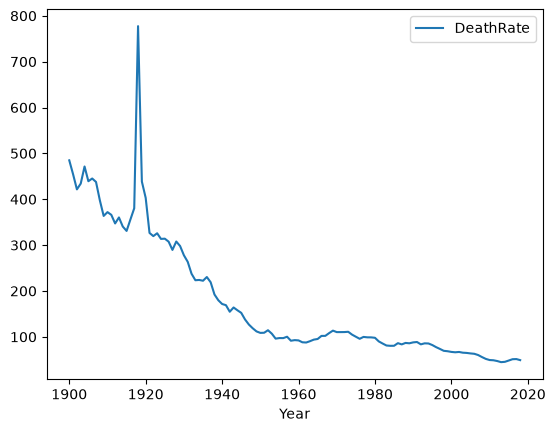

In [12]:
mortality_group.plot(x='Year', y='DeathRate')

In [14]:
mortality_group.query('DeathRate > 500')

,Year,AgeGroup,DeathRate
375,1918,15-19 Years,777.4


## How to fix outliers

In [18]:
mortality_group = pd.read_pickle('./data/mortality_group.pkl')
# Filter the 'mortality_group' dataframe to include only rows where 
# the 'DeathRate' is less than or equal to 500
mortality_group = mortality_group.query('DeathRate <= 500')

In [20]:
mortality_group = pd.read_pickle('./data/mortality_group.pkl')
# Replace any values in the 'DeathRate' column of 'mortality_group' 
# that are greater than 500 with the value 450
mortality_group.loc[mortality_group.DeathRate > 500, 'DeathRate'] = 450

In [ ]:
mortality_group = pd.read_pickle('./data/mortality_group.pkl')
# Replace any values in the 'DeathRate' column of 'mortality_group' 
# that are greater than 500 with the mean of the 'DeathRate' column
mortality_group.loc[mortality_group.DeathRate > 500, 'DeathRate'] = mortality_group.DeathRate.mean()
# Create a line plot of the 'DeathRate' column of the 
#'mortality_group' dataframe, with 'Year' as the x-axis
mortality_group.plot(x='Year', y='DeathRate')

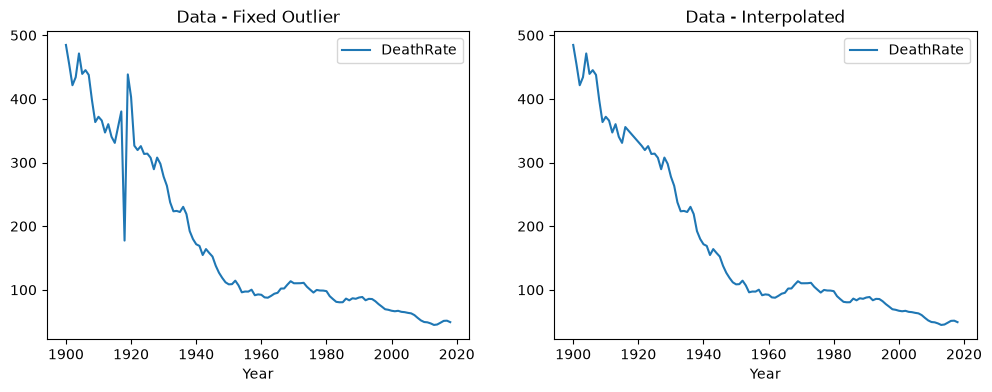

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

mortality_group = pd.read_pickle('./data/mortality_group.pkl')
# Set DeathRate values greater than 500 to the mean DeathRate
mortality_group.loc[mortality_group.DeathRate > 500, 'DeathRate'] = mortality_group.DeathRate.mean()
# Create two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# fig: the entire figure or canvas.
# axs: an array containing the two subplot axes.
# 1, 2: one row and two columns.
# figsize=(12, 4): the figure is 12 inches wide and 4 inches high.
# Plot DeathRate against Year in the first subplot
mortality_group.plot(x='Year', y='DeathRate', ax=axs[0])
axs[0].set_title('Data - Fixed Outlier')
# Set DeathRate values for certain years to None
mortality_group.loc[mortality_group.Year.isin([1917,1918,1919,1920]), 'DeathRate'] = None
# Interpolate missing DeathRate values
mortality_group['DeathRate'] = (
    mortality_group['DeathRate'].interpolate()
)
# mortality_group = mortality_group.interpolate() # attempts to interpolate every column, including text columns.
# Plot DeathRate against Year again in the second subplot
mortality_group.plot(x='Year', y='DeathRate', ax=axs[1])
axs[1].set_title('Data - Interpolated')
# Show the plot
plt.show()